<a href="https://colab.research.google.com/github/Olga-Lyt/Analysis_Cafe_Sales/blob/main/EDA_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis_Cafe_Sales  

Cafe Sales - Dirty Data for Cleaning Training  

Dirty Cafe Sales Dataset
Overview
The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

File Information
File Name: dirty_cafe_sales.csv
Number of Rows: 10,000
Number of Columns: 8

| Column Name | Description | Example Values |
| ----------- | ----------- | -------------- |
| `Transaction ID` | A unique identifier for each transaction. Always present and unique. | `TXN_1234567` |
| `Item` | The name of the item purchased. May contain missing or invalid values (e.g., "ERROR"). | `Coffee`, `Sandwich` |
| `Quantity` | The quantity of the item purchased. May contain missing or invalid values. | `1`, `3`, `UNKNOWN` |
| `Price Per Unit` | The price of a single unit of the item. May contain missing or invalid values. | `2.00`, `4.00` |
| `Total Spent` | The total amount spent on the transaction. Calculated as `Quantity * Price Per Unit`. | `8.00`, `12.00` |
| `Payment Method` | The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN"). | `Cash`, `Credit Card` |
| `Location` | The location where the transaction occurred. May contain missing or invalid values. | `In-store`, `Takeaway`
| `Transaction Date` | The date of the transaction. May contain missing or incorrect values. | `2023-01-01` |  



In [62]:
pip install numpy pandas matplotlib

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Шлях до файлів

In [64]:
# FILE_IN = "data/cafe_sales.csv"
FILE_IN = 'https://raw.githubusercontent.com/KsiuTretyakova/Analysis_Cafe_Sales_DTA2026/refs/heads/main/data/dirty_cafe_sales.csv'
# FILE_OUT = "data/cafe_sales_clean.csv"
FILE_OUT = "cafe_sales_clean.csv"

## Loading dataset  
Завантаження датасету

In [65]:
url = 'https://raw.githubusercontent.com/Olga-Lyt/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

df_origin = pd.read_csv(url)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [66]:
df = df_origin.copy()

## Primary diagnosis   
Первинна діагностика  


In [67]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [69]:
print("Data types (raw):\n")
df.dtypes

Data types (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:  
- ` Numeric columns (Quantity, Price Per Unit, Total Spent)  

- ` Date columns (Transaction Date)

In [70]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [71]:
print("Unique values:\n")
print("---Item---\n")
display(df['Item'].value_counts(dropna=False))

print("\n---Payment Method---\n")
display(df['Payment Method'].value_counts(dropna=False))

print("\n---Location---\n")
display(df['Location'].value_counts(dropna=False))

Unique values:

---Item---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



---Payment Method---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



---Location---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [72]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
#df.isin(['ERROR', 'UNKNOWN']).any()
mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"Lines with 'ERROR', or 'UNKNOWN': {mask_error.sum()}")

Find lines with 'ERROR' or 'UNKNOWN'

Lines with 'ERROR', or 'UNKNOWN': 2845


ДЗ: Замість записати кількість ERROR/UNKNOWN

In [73]:
print("Find lines with 'ERROR' or 'UNKNOWN'\n")
#df.isin(['ERROR', 'UNKNOWN']).any()
mask_error = df.isin(['ERROR', 'UNKNOWN']).sum()
print(f"Lines with 'ERROR', or 'UNKNOWN': {mask_error.sum()}")

Find lines with 'ERROR' or 'UNKNOWN'

Lines with 'ERROR', or 'UNKNOWN': 3256


## Data cleaning


На цьому етапі робимо копію, якщо не зробили раніше

'df_origin` - оригінальний датасет
'df` - копія датасету

In [74]:
print("Rename columns:\n")

df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_unit',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'

})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [75]:
"  Transaction Date  ".strip().lower().replace(" ", "_")



'transaction_date'

In [76]:
"  Transaction    Date  ".strip().lower().replace(" ", "_")

'transaction____date'

In [77]:
"_".join("   Transaction Date   ".lower().split())

'transaction_date'

In [78]:
df.columns.str.lower().str.replace(" ", "_")

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

In [79]:
# 'ERROR'/'UNKNOWN' -> NaN
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Змінюємо типи даних

In [80]:
for col in ['quantity', 'price_per_unit', 'total_spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')   # якщо дані не числові, то перетворює на null

df.dtypes

,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,object


In [81]:
df['transaction_date'] = df_origin['Transaction Date'].copy()  # якщо сталася помилка з назвою колонки, то можна взяти дані з оригіналу

In [82]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [83]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')   # перетворює дані колонки на дату

df.dtypes

,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [84]:
# Витягуємо додаткові часові ознаки, тобто з стовпчика дати формуємо нові показники

df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int64')
# df['month'] = df['transaction_date'].dt.month_name()
df['month_name'] = df['transaction_date'].dt.strftime('%B')  # дата відформатована в формат рядка A,a - день  B,b - місяць, Y,y - рік
df['weekday'] = df['transaction_date'].dt.day_name()  #  день тижня
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int64')   # № тижня в році
df[['transaction_date', 'year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,September,Friday,36
1,2023-05-16,2023,5,May,Tuesday,20
2,2023-07-19,2023,7,July,Wednesday,29
3,2023-04-27,2023,4,April,Thursday,17
4,2023-06-11,2023,6,June,Sunday,23


In [85]:
# Заповнення значень стовпчика total_spent: total_spent = quantity * price_per_unit
mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit']. notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_unit']
)

print(f"Restoring total spent: {mask_recoverable.sum()} string (quantity * price_per_unit) ")


Restoring total spent: 462 string (quantity * price_per_unit) 


In [86]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023,5,May,Tuesday,20
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023,7,July,Wednesday,29
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,2023,4,April,Thursday,17
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023,6,June,Sunday,23


In [87]:
price_map = (
    df.dropna(subset=['item', 'price_per_unit'])
    .groupby('item')['price_per_unit']
    .median()
    .to_dict()
)

mask_price = df['price_per_unit'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_unit'] = df.loc[mask_price, 'item'].map(price_map)  # пошук та заміна значень через loc

print(f"Restoring price_per_unit: {mask_price.sum()} string (median per item) ")

Restoring price_per_unit: 479 string (median per item) 


In [88]:
# Заповнення значень стовпчика total_spent виходячи з нових значень ціни: total_spent = quantity * new_price_per_unit
mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_unit']. notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_unit']
)

print(f"Restoring total spent: {mask_recoverable2.sum()} string (new price - median item) ")

Restoring total spent: 17 string (new price - median item) 


In [89]:
# Заповнюємо стовпчик item найпопулярнішим товаром mode_item
mode_item = df['item'].mode()[0]
# df['item'].fillna(mode_item, inplace=True)   # застарілий варіант
df.fillna({'item': mode_item}, inplace=True)


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              10000 non-null  object        
 2   quantity          9521 non-null   float64       
 3   price_per_unit    9946 non-null   float64       
 4   total_spent       9977 non-null   float64       
 5   payment_method    6822 non-null   object        
 6   location          6039 non-null   object        
 7   transaction_date  9540 non-null   datetime64[ns]
 8   year              9540 non-null   Int64         
 9   month             9540 non-null   Int64         
 10  month_name        9540 non-null   object        
 11  weekday           9540 non-null   object        
 12  week              9540 non-null   Int64         
dtypes: Int64(3), datetime64[ns](1), float64(3), object(6)
memory usage: 1.0+ MB


In [91]:
# payment_method та location залишаємо невідомими, тобто заповнюємо Unknown
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              10000 non-null  object        
 2   quantity          9521 non-null   float64       
 3   price_per_unit    9946 non-null   float64       
 4   total_spent       9977 non-null   float64       
 5   payment_method    10000 non-null  object        
 6   location          10000 non-null  object        
 7   transaction_date  9540 non-null   datetime64[ns]
 8   year              9540 non-null   Int64         
 9   month             9540 non-null   Int64         
 10  month_name        9540 non-null   object        
 11  weekday           9540 non-null   object        
 12  week              9540 non-null   Int64         
dtypes: Int64(3), datetime64[ns](1), float64(3), object(6)
memory usage: 1.0+ MB


In [93]:
# Видалення transaction_date де замість дати стоїть NaT або NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)
print(f"Deleted {before - after} rows")

Deleted 914 rows


In [94]:
df.isna().sum()

,0
transaction_id,0
item,0
quantity,0
price_per_unit,48
total_spent,3
payment_method,0
location,0
transaction_date,0
year,0
month,0



Перевірка та при потребі прибирання дублікатів


In [95]:
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week'],
      dtype='object')

In [96]:
df[['item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week']].duplicated().sum()

np.int64(192)

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df.drop_duplicates(inplace=True)  # видалення дублікатів за необхідності

Перевірка на логічність даних. Вони не повинні бути від'ємними

In [99]:
(df.quantity <= 0).sum()  # 0
(df.price_per_unit <= 0).sum()  # 0
(df.total_spent <= 0).sum()  # 0

np.int64(0)

In [100]:
(df['quantity'].isna() & df['price_per_unit'].isna()).sum()

np.int64(0)

In [101]:
#Restoring price_per_unit (total_spent / quantity)
mask_recoverable3 = (
    df['price_per_unit'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)
df.loc[mask_recoverable3, 'price_per_unit'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()
print(f"Restoring price_per_unit: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_unit: 45 (total_spent / quantity)


In [102]:
df.isna().sum()

,0
transaction_id,0
item,0
quantity,0
price_per_unit,3
total_spent,3
payment_method,0
location,0
transaction_date,0
year,0
month,0


In [103]:

df.dropna(subset=['total_spent'], inplace=True)
print(f"Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())")

Delete rows with NaN (df['total_spent'].isna() & df['price_per_unit'].isna())


In [104]:
# Check quantity * price_per_unit = total_spent
mask_total_spent = (df.quantity * df.price_per_unit != df.total_spent)
print(f"Uncorrect rows total_spent: {mask_total_spent.sum()}")

Uncorrect rows total_spent: 0


In [105]:
for col in ['item', 'payment_method', 'location']:   #стандартизація текстових полів
    df[col] = df[col].str.strip().str.title()
print("Text fields are standartizied (Title Case)")

Text fields are standartizied (Title Case)


## Cleaning result
Результати очистки

In [106]:
# df_origin = name_your_origin_DataFrame
# df = name_your_clean_DataFrame

print("Cleaning results:\n")
print('=' * 20)

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("\n---Residual gaps---")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("Data types after cleanup: ")
display(df.dtypes)   # print(df.dtypes)

print("\n---Statistics---")
print(df[['quantity', 'price_per_unit', 'total_spent']].describe().round(2))

Cleaning results:

Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

---Residual gaps---
No gaps
Data types after cleanup: 


,0
transaction_id,object
item,object
quantity,float64
price_per_unit,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,Int64
month,Int64



---Statistics---
       quantity  price_per_unit  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


## Feature Engineering


In [107]:
# Досліджуємо сезонність
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

df[['month', 'season']].head()

,month,season
0,9,Autumn
1,5,Spring
2,7,Sommer
3,4,Spring
4,6,Sommer


In [108]:
# перевірка який день тижня вихідний
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])


In [109]:
# Check amount category
# Дослідження розміру покупки за категорією
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'High', 'Premium']
)


In [110]:
print("New attributes: season, is_weekend, spend_tier")

New attributes: season, is_weekend, spend_tier


In [111]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,September,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,May,Tuesday,20,Spring,False,High
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,July,Wednesday,29,Sommer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,April,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,June,Sunday,23,Sommer,True,Low


In [112]:
df['total_spent'].describe()

,total_spent
count,9083.000000
mean,8.933172
std,5.997861
min,1.000000
25%,4.000000
50%,8.000000
75%,12.000000
max,25.000000


## Fast EDA (побудова графіків)

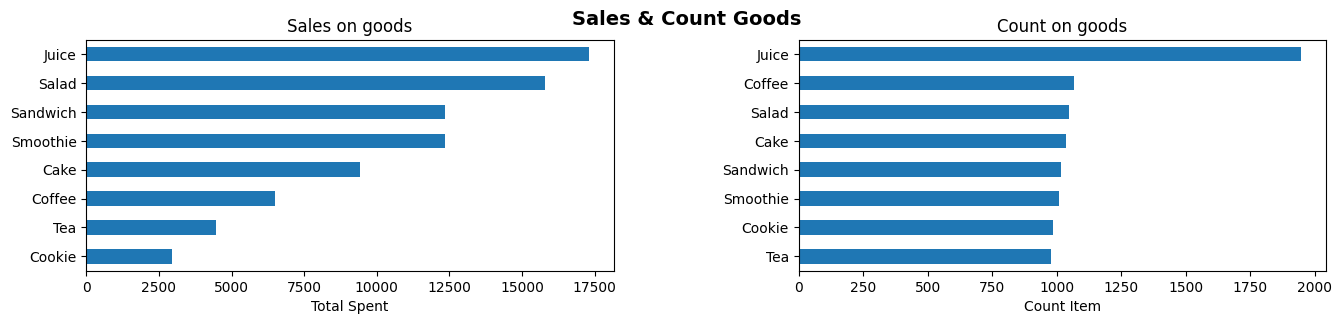

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(16, 3))
fig.suptitle("Sales & Count Goods", fontsize=14, fontweight='bold')
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item
ax = axes[0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh',ax=ax)
ax.set_title("Sales on goods")
ax.set_xlabel("Total Spent")
ax.set_ylabel("")


# count per item
ax = axes[1]   #axes[0, 1]
df['item'].value_counts().sort_values().plot(kind='barh', ax = ax)
ax.set_title("Count on goods")
ax.set_xlabel("Count Item")
ax.set_ylabel("")
plt.show()


In [114]:
# df.groupby('item')['total_spent'].sum().sort_values().plot.barh();   - приклад графіку

In [115]:
set(list(df['month_name'].values))   # Вибираємо иісяці, які у нас є

{'April',
 'August',
 'December',
 'February',
 'January',
 'July',
 'June',
 'March',
 'May',
 'November',
 'October',
 'September'}

In [116]:
#  Як витягнути назви місяців кодом:
import calendar
print([calendar.month_name[i] for i in range(1, 13)])

['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']


In [117]:
# Продажі по місяцях
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df.groupby('month_name')['total_spent'].sum()



,total_spent
month_name,
April,6782.5
August,6756.5
December,6835.5
February,6347.5
January,6894.5
July,6700.5
June,7010.0
March,6931.0
May,6607.5


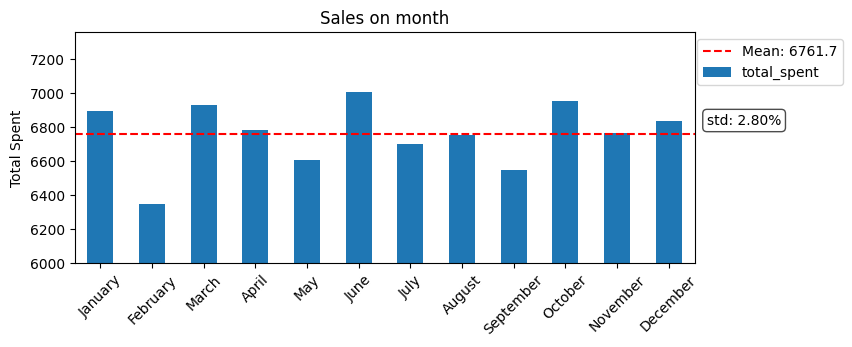

In [118]:
# Продажі по місяцях побудова графіку
fig = plt.figure(figsize=(8,3))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# print(df.groupby('month_name')['total_spent'].sum())


# Змінюємо послідовність місяців

rev_month = df.groupby('month_name')['total_spent'].sum().reindex(
    [m for m in month_order if m in df['month_name'].unique()]

)

rev_month.plot(kind='bar', rot=45)

mean_value = rev_month.mean()
std_value = rev_month.std()  # Стандартне відхилення
std_pct = (std_value / mean_value) * 100  #  Стандартне відхилення у %
# print(mean_value)
plt.axhline(y=mean_value, color='red', linestyle='--', linewidth=1.5, label=f"Mean: {mean_value:.1f}")

plt.ylim(bottom=6000)   # Змінюємо початок з 0 до 6000

plt.title("Sales on month")
plt.xlabel("")
plt.ylabel("Total Spent")
plt.legend(bbox_to_anchor=(1.25, 1),loc='upper right') # розміщення позначок

plt.text(1.02, 0.6, f"std: {std_pct:.2f}%", transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round, pad=0.3', facecolor='white', alpha=0.7)
         )  # оформлення підпису std: 2.80%
plt.show()

Додати графіки за власним поглядом

In [119]:
plt.savefig('cafe_eda.png', dpi=150, bbox_inches='tight')  # вставляти перед plt.show()

<Figure size 640x480 with 0 Axes>

## saving a clean CSV for Tableau

In [120]:
len(df.columns)
df.shape

(9083, 16)

In [121]:
# df['transaction_date'] = df_origin['Transaction Date'].copy()
# df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [126]:
# форматування дати для Tableau YYYY-MM-DD

try:
    df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')
except:
    print("transaction_date was change - (%Y-%m-%d)\n")

#df['transaction_date'] = df['transaction_date'].dt.strftime('%Y-%m-%d')
# Для Tableau заміняємо бульове значення на рядок
df['is_weekend'] = df['is_weekend'].map({
    True: 'Yes',
    False: 'No'
})

df.to_csv(FILE_OUT, index=False, encoding='utf-8-sig')

print(f"Saved: {FILE_OUT}")
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")

transaction_date was change - (%Y-%m-%d)

Saved: cafe_sales_clean.csv
Rows: 9083 | Columns: 16


## Summary report
Підсумковий звіт

In [137]:
print(f"Total revenue:          {df['total_spent'].sum():>14,.2f}")
print(f"Number of transactions: {len(df):>14,.2f}")
print(f"Average check:          {df['total_spent'].mean():>14,.2f}")
print(f"Median check:           {df['total_spent'].median():>14,.2f}")
print(f"Unique products:        {df['item'].nunique():>14,.2f}")
# print(f"Unique locations: {df['location'].nunique():>14,.2f}")

all_location = df.loc[df['location'] != "Unknown", 'location']
print(f"Unique locations:       {all_location.nunique():>14,}")

top_item = df.groupby('item')['total_spent'].sum().idxmax()
print(f"Top profitable product: {top_item:>14}")

# top_pay = df['payment_method'].value_counts()
# top_pay.dop('Unknown', errors='ignore').idxmax()

all_pay_method = df.loc[df['payment_method'] != "Unknown", 'payment_method']
top_pay = all_pay_method.value_counts().idxmax()

print(f"Unique payment method:  {all_pay_method.nunique():>14,.2f}")
print(f"Top payment method:     {top_pay:>14}")




Total revenue:               81,140.00
Number of transactions:       9,083.00
Average check:                    8.93
Median check:                     8.00
Unique products:                  8.00
Unique locations:                    2
Top profitable product:          Juice
Unique payment method:            3.00
Top payment method:     Digital Wallet
